In [1]:
# Import libraries
import pandas as pd
from IPython.display import display

# Load your datasets
app_df = pd.read_csv('application_record.csv')
credit_df = pd.read_csv('credit_record.csv')

# Show top rows
display(app_df.head())
display(credit_df.head())


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [3]:
# Check column names
print("Application data columns:\n", app_df.columns)
print("\nCredit data columns:\n", credit_df.columns)


Application data columns:
 Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'],
      dtype='object')

Credit data columns:
 Index(['ID', 'MONTHS_BALANCE', 'STATUS'], dtype='object')


In [5]:
# Define bad credit statuses
bad_status = ['1', '2', '3', '4', '5']

# Flag defaults
credit_df['defaulted'] = credit_df['STATUS'].isin(bad_status).astype(int)

# One row per person: did they default at least once?
target_df = credit_df.groupby('ID')['defaulted'].max().reset_index()

# Preview
display(target_df.head())


,ID,defaulted
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


In [9]:
# Merge app_df with target
merged_df = app_df.merge(target_df, on='ID', how='left')

# People not in credit_df → assume no default
merged_df['defaulted'] = merged_df['defaulted'].fillna(0).astype(int)

# Check target distribution
print(merged_df['defaulted'].value_counts(normalize=True))
merged_df.head()


defaulted
0    0.990216
1    0.009784
Name: proportion, dtype: float64


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,defaulted
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,1
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,0


In [13]:
from IPython.display import display

# Keep ID separately (optional, for later use)
id_col = merged_df['ID']

# Create X and y
X = merged_df.drop(['ID', 'defaulted'], axis=1)
y = merged_df['defaulted']

# 👁️‍🗨️ Display updated features
display(X.head())


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [15]:
# 👁️‍🗨️ Show missing values per column
missing = X.isnull().sum().sort_values(ascending=False)
display(missing[missing > 0])


OCCUPATION_TYPE    134203
dtype: int64

In [17]:
# Encode categorical columns with one-hot encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# 👁️‍🗨️ Show encoded DataFrame
display(X_encoded.head())


,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,CODE_GENDER_M,...,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff
0,0,427500.0,-12005,-4542,1,1,0,0,2.0,True,...,False,False,False,False,False,False,False,False,False,False
1,0,427500.0,-12005,-4542,1,1,0,0,2.0,True,...,False,False,False,False,False,False,False,False,False,False
2,0,112500.0,-21474,-1134,1,0,0,0,2.0,True,...,False,False,False,False,False,False,False,False,True,False
3,0,270000.0,-19110,-3051,1,0,1,1,1.0,False,...,False,False,False,False,False,False,True,False,False,False
4,0,270000.0,-19110,-3051,1,0,1,1,1.0,False,...,False,False,False,False,False,False,True,False,False,False


In [19]:
# Fill remaining missing values
X_encoded = X_encoded.fillna(X_encoded.median())

# 👁️‍🗨️ Confirm no more missing values
display(X_encoded.isnull().sum().sort_values(ascending=False).head())


CNT_CHILDREN                             0
OCCUPATION_TYPE_High skill tech staff    0
NAME_HOUSING_TYPE_Municipal apartment    0
NAME_HOUSING_TYPE_Office apartment       0
NAME_HOUSING_TYPE_Rented apartment       0
dtype: int64

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

# 👁️‍🗨️ Show training features
display(X_train.head())


,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,CODE_GENDER_M,...,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff
76809,2,112500.0,-13883,-232,1,1,1,0,4.0,False,...,False,False,False,False,False,False,True,False,False,False
108731,0,180000.0,-9361,-336,1,0,0,0,2.0,False,...,False,False,False,False,False,False,False,True,False,False
205186,1,90000.0,-13602,-2248,1,0,0,0,3.0,False,...,False,False,False,False,False,False,True,False,False,False
357109,0,315000.0,-17936,-110,1,1,1,0,2.0,False,...,False,False,False,False,False,False,False,False,False,False
31012,0,135000.0,-11088,-1447,1,0,1,0,2.0,False,...,False,False,False,False,False,False,False,False,False,False


In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# 👁️‍🗨️ Show balanced training set
print("After SMOTE - Class distribution:")
print(y_train_sm.value_counts(normalize=True))

# 👁️‍🗨️ Show a sample of resampled features
display(X_train_sm[:5])


After SMOTE - Class distribution:
defaulted
0    0.5
1    0.5
Name: proportion, dtype: float64


,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,CODE_GENDER_M,...,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff
0,2,112500.0,-13883,-232,1,1,1,0,4.0,False,...,False,False,False,False,False,False,True,False,False,False
1,0,180000.0,-9361,-336,1,0,0,0,2.0,False,...,False,False,False,False,False,False,False,True,False,False
2,1,90000.0,-13602,-2248,1,0,0,0,3.0,False,...,False,False,False,False,False,False,True,False,False,False
3,0,315000.0,-17936,-110,1,1,1,0,2.0,False,...,False,False,False,False,False,False,False,False,False,False
4,0,135000.0,-11088,-1447,1,0,1,0,2.0,False,...,False,False,False,False,False,False,False,False,False,False


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
)


In [35]:
def train_and_evaluate(model, model_name):
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"🔍 Results for {model_name}")
    print("-----------------------------------")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    RocCurveDisplay.from_predictions(y_test, y_prob)


C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


🔍 Results for Logistic Regression
-----------------------------------
              precision    recall  f1-score   support

           0       0.99      0.84      0.91     86854
           1       0.01      0.18      0.02       858

    accuracy                           0.83     87712
   macro avg       0.50      0.51      0.47     87712
weighted avg       0.98      0.83      0.90     87712

ROC-AUC Score: 0.5132


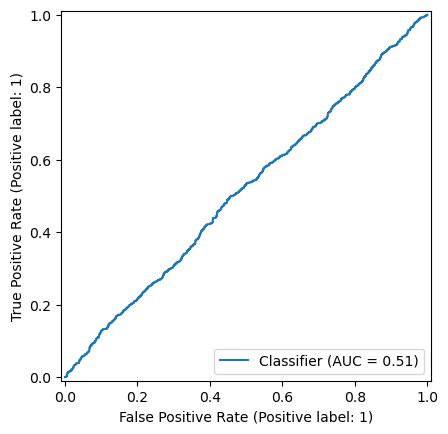

In [38]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
train_and_evaluate(log_model, "Logistic Regression")


🔍 Results for Random Forest
-----------------------------------
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     86854
           1       0.31      0.40      0.35       858

    accuracy                           0.99     87712
   macro avg       0.65      0.70      0.67     87712
weighted avg       0.99      0.99      0.99     87712

ROC-AUC Score: 0.8324


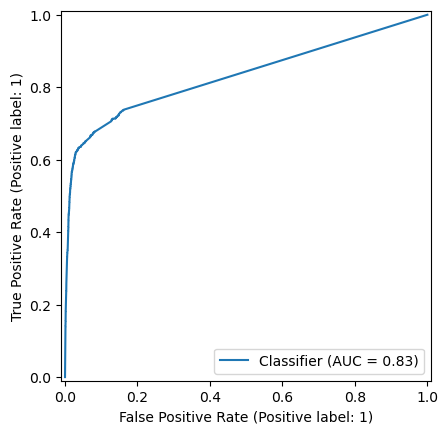

In [39]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
train_and_evaluate(rf_model, "Random Forest")


C:\Users\User\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [18:07:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔍 Results for XGBoost
-----------------------------------
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     86854
           1       0.10      0.23      0.14       858

    accuracy                           0.97     87712
   macro avg       0.55      0.61      0.56     87712
weighted avg       0.98      0.97      0.98     87712

ROC-AUC Score: 0.6647


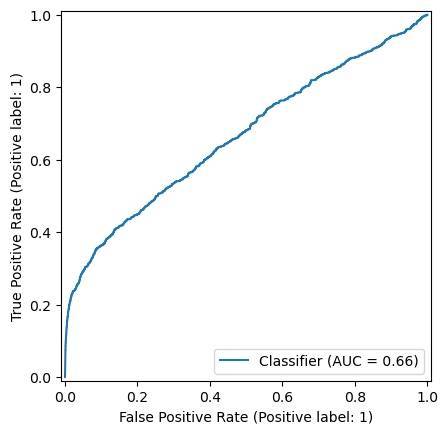

In [41]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
train_and_evaluate(xgb_model, "XGBoost")


In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from the Random Forest model
importances = rf_model.feature_importances_

# Match them with column names
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the top 20 features
print(importance_df.head(20))


                                              Feature  Importance
2                                          DAYS_BIRTH    0.147396
1                                    AMT_INCOME_TOTAL    0.122134
8                                     CNT_FAM_MEMBERS    0.104314
3                                       DAYS_EMPLOYED    0.098160
16               NAME_EDUCATION_TYPE_Higher education    0.045606
19  NAME_EDUCATION_TYPE_Secondary / secondary special    0.036760
22            NAME_FAMILY_STATUS_Single / not married    0.031004
20                         NAME_FAMILY_STATUS_Married    0.029014
6                                          FLAG_PHONE    0.027046
0                                        CNT_CHILDREN    0.026239
9                                       CODE_GENDER_M    0.024898
15                           NAME_INCOME_TYPE_Working    0.023137
10                                     FLAG_OWN_CAR_Y    0.020978
11                                  FLAG_OWN_REALTY_Y    0.019930
36        

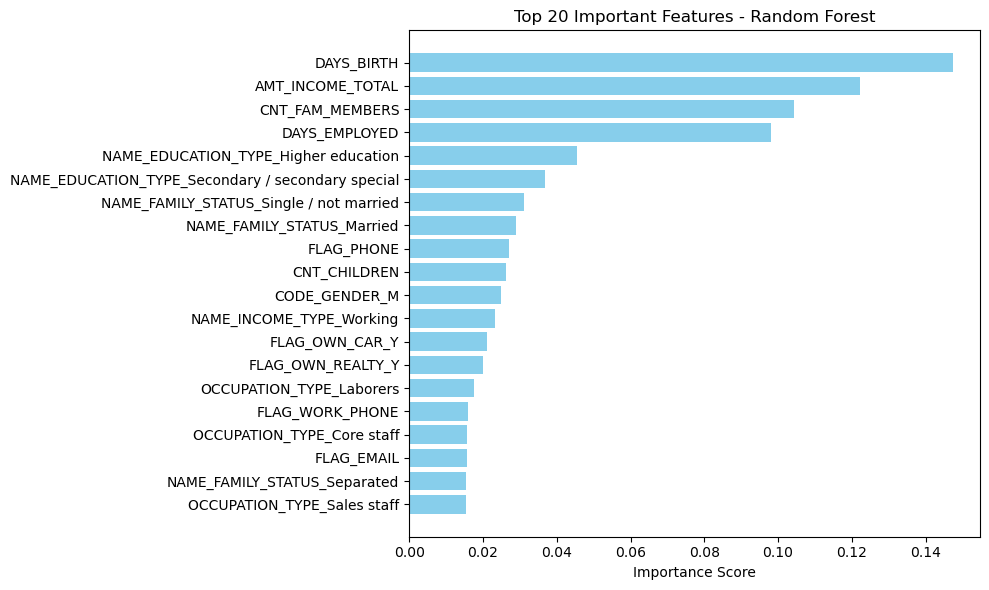

In [46]:
# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df.head(20)['Feature'], importance_df.head(20)['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 20 Important Features - Random Forest')
plt.gca().invert_yaxis()  # Most important on top
plt.tight_layout()
plt.show()


In [50]:
# Prepare full dataset for prediction (without target, but with ID)
X_full = merged_df.drop(columns=['defaulted'])

# Store the IDs separately
ids = merged_df['ID']

# 👁️‍🗨️ Display the full dataset (first 5 rows)
X_full.head()


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [54]:
# Drop target column
X_full = merged_df.drop(columns=['defaulted'])

# Store ID separately
ids = merged_df['ID']

# Apply same encoding used on X_train
X_full_encoded = pd.get_dummies(X_full)

# Align columns with training data
X_full_encoded = X_full_encoded.reindex(columns=X_train.columns, fill_value=0)

# Display to confirm
X_full_encoded.head()


,CNT_CHILDREN,AMT_INCOME_TOTAL,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,CODE_GENDER_M,...,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff
0,0,427500.0,-12005,-4542,1,1,0,0,2.0,True,...,False,False,False,False,False,False,False,False,False,False
1,0,427500.0,-12005,-4542,1,1,0,0,2.0,True,...,False,False,False,False,False,False,False,False,False,False
2,0,112500.0,-21474,-1134,1,0,0,0,2.0,True,...,False,False,False,False,False,False,False,False,True,False
3,0,270000.0,-19110,-3051,1,0,1,1,1.0,False,...,False,False,False,False,False,False,True,False,False,False
4,0,270000.0,-19110,-3051,1,0,1,1,1.0,False,...,False,False,False,False,False,False,True,False,False,False


In [56]:
# Predict default probabilities (class 1)
default_probs = rf_model.predict_proba(X_full_encoded)[:, 1]

# Combine with IDs
risk_scores_df = pd.DataFrame({
    'ID': ids,
    'default_probability': default_probs
})

# Sort and display top risky customers
risk_scores_df_sorted = risk_scores_df.sort_values(by='default_probability', ascending=False)
risk_scores_df_sorted.head(10)


,ID,default_probability
0,5008804,1.0
14367,5041370,1.0
46037,5139807,1.0
46036,5139806,1.0
14609,5041718,1.0
14610,5041719,1.0
14611,5041720,1.0
14612,5041721,1.0
14613,5097185,1.0
45882,5137516,1.0


In [58]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predict on test set
y_pred = rf_model.predict(X_test)

# Classification metrics
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

print("\n✅ Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC AUC Score
roc_score = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
print(f"\n🧠 ROC AUC Score: {roc_score:.4f}")


📊 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     86854
           1       0.31      0.40      0.35       858

    accuracy                           0.99     87712
   macro avg       0.65      0.70      0.67     87712
weighted avg       0.99      0.99      0.99     87712


✅ Confusion Matrix:
[[86095   759]
 [  514   344]]

🧠 ROC AUC Score: 0.8324
